# Toolkit for Measuring Contextual Individuation in Transformer Language Models

This notebook tests whether a transformer language model **individuates** a
word's use by context, even when the word itself is held fixed.

A **bridge form** is a single written word (grapheme) that occurs, unchanged,
across two or more subject areas with a different sense each time - e.g.
`current` as "electric current" (physics), "current account" (finance) and
"ocean current" (physical geography). Because every occurrence of a bridge
form shares the same entry in the model's vocabulary, the model's *static*
embedding layer (`hs[0]`) cannot tell the occurrences apart: it assigns them,
up to positional noise, the same vector. Any separation that appears in later
layers can only come from **context**, not from the word type itself - that
is the structural guarantee the whole design rests on.

The full design rationale for every choice this notebook makes is documented
in its companion manuscript, *Technical Manual for a Toolkit for Measuring
Contextual Individuation in Transformer Language Models*.

**Pipeline:**
1. Declare, per bridge form, which subject areas it should bridge and which
   Wikipedia category supplies each area's text (`BRIDGE_FORMS`).
2. Fetch a corpus of article introductions from those categories.
3. Locate every occurrence of each bridge form in that corpus.
4. Run the chosen model and keep the hidden state of the bridge form's own
   token, at every layer, for every occurrence.
5. Measure separation between subject areas with the **silhouette
   coefficient** (cosine distance), layer by layer, one subject-area pair at
   a time.
6. Visualise the same occurrences with a shared 2D PCA projection, at the
   first and last layer, alongside the silhouette curves.

**Running this notebook:** loading and running a transformer model has a
real computational cost. This notebook processes **one model at a time** -
see the `MODEL_INDEX` constant in the model-selection section. To compare
another architecture, change that index and re-run the whole notebook;
running every candidate model in a single pass is deliberately not
automated here.

In [1]:
# Uncomment the line below if running on Google Colab, or any environment
# without these packages already installed.
# !pip install torch transformers scikit-learn matplotlib numpy requests python-dotenv

import os
import re
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from dotenv import load_dotenv
from matplotlib.colors import to_rgb
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from transformers import AutoModel, AutoTokenizer

c:\.tools\contextual_individuation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Model

`MODELS_LIST` records the architectures this design has been checked
against; `MODEL_INDEX` selects which one this run uses. Change the index and
re-run the whole notebook to test a different model - each run reports
results for exactly one, given the computational cost of running several.

Model families differ in ways that matter here: BERT/RoBERTa/DistilBERT/
DeBERTa are bidirectional encoders (a token's representation can draw on the
whole sentence); GPT-2 and Pythia are causal decoders (a token can only draw
on what came *before* it). A bridge form appearing early in a sentence has
less context available to it under a causal model - a difference to keep in
mind when comparing results across the list, not a defect in either family.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

MODELS_LIST = [
    'bert-base-uncased',
    'roberta-base',
    'distilbert-base-uncased',
    'microsoft/deberta-base',
    'gpt2',
    'EleutherAI/pythia-410m',
]

MODEL_INDEX = 0  # change this to run a different model, then re-run the notebook
MODEL_NAME = MODELS_LIST[MODEL_INDEX]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.eval()

print(f'Loaded "{MODEL_NAME}"')

Device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12230.98it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded "bert-base-uncased"


## 2. Bridge forms

Each bridge form maps its subject areas directly to a **specific** Wikipedia
category - not a broad, shared one. A broad category (e.g. `Geography`) mixes
senses (economic geography alongside physical geography) and contaminates
the group with occurrences that do not carry the sense the panel is supposed
to isolate. Categories are declared per form, per subject area, before any
geometry is computed - a bridge form is only informative if what counts as
"one occurrence of a given sense" is decided in advance, not chosen after
seeing which choice produces a cleaner result.

Comparisons are kept **pairwise** throughout (see the silhouette section
below): with three or more subject areas pooled together, the silhouette's
between-group term is the distance to the *nearest* other group only, so two
areas that happen to sit close to each other in the model's geometry drag
each other's score down while an isolated third area looks artificially
clean. Computing one pair at a time removes that ambiguity.

Only `current` is active below. The remaining candidates are commented out
with their old, broad categories as a starting point - they still need
specific categories chosen deliberately, the same way `current`'s were,
before being reactivated.

In [3]:
# Each bridge form maps its subject areas to a specific Wikipedia category.
BRIDGE_FORMS = {
    "current":      {"physics":    "Electricity", "economics":  "Finance","geography":  "Physical geography",},
    "bank":         {"economics": "Banking", "geography": "Rivers"},
    "field":        {"physics": "Electromagnetism", "mathematics": "Abstract algebra", "sociology": "Sociological theory"},
    "mass":         {"physics": "Classical mechanics", "sociology": "Mass media", "history": "Social movements"},
    "wave":         {"physics": "Waves", "sociology": "Protest", "history": "Historical migrations"},
    "charge":       {"physics": "Electromagnetism", "chemistry": "Ions", "political_science": "Criminal law"},
    "cell":         {"biology": "Cell biology", "computer_science": "Computer memory", "political_science": "Terrorism"},
    # "network":      {"computer_science": "Computer networking", "sociology": "Social networks", "biology": "Neuroscience"},
    # "model":        {"mathematics": "Mathematical modeling", "computer_science": "Machine learning", "sociology": "Social theory", "business": "Business models"},
    # "value":        {"mathematics": "Elementary algebra", "philosophy": "Ethics", "economics": "Valuation (finance)"},
    # "matter":       {"physics": "States of matter", "philosophy": "Metaphysics"},
    # "state":        {"physics": "States of matter", "political_science": "Sovereign states", "computer_science": "Automata theory"},
    # "power":        {"physics": "Power (physics)", "political_science": "Political philosophy", "mathematics": "Elementary algebra"},
    # "domain":       {"mathematics": "Mathematical analysis", "computer_science": "Domain name system", "biology": "Protein structure"},
    # "vector":       {"mathematics": "Linear algebra", "biology": "Disease vectors"},
    # "resistance":   {"physics": "Electrical resistance and conductance", "medicine": "Antimicrobial resistance", "political_science": "Resistance movements"},
    # "stress":       {"engineering": "Solid mechanics", "psychology": "Psychological stress", "medicine": "Stress-related disorders"},
    # "bond":         {"chemistry": "Chemical bonding", "economics": "Bonds (finance)", "sociology": "Interpersonal relationships"},
    # "culture":      {"biology": "Cell culture", "sociology": "Cultural anthropology"},
    # "conservation": {"physics": "Conservation laws", "environmental_science": "Nature conservation"},
}

## 3. Corpus: Wikipedia article introductions

Two calls to the MediaWiki API build the corpus for one category:

1. `list=categorymembers` - the articles directly in the category, plus the
   articles of its direct subcategories (one level deep). A Wikipedia
   category by itself often holds few articles directly; almost everything
   sits one level down, in subcategories - going one level down is a large
   gain in volume without walking the whole category tree.
2. `prop=extracts` with `exintro=True` - the **introduction only** of each
   article, in plain text. The full text of an article is not fetched:
   introductions are Wikipedia's own version of a comparable, abstract-length
   unit - not skewed by whichever article happens to be longest, the same
   reasoning that favoured abstracts over full papers in this project's
   OpenAlex iteration.

A documented API quirk, found by trial and error: `prop=extracts` accepts
multiple titles per request, but caps the number of pages that receive a
**full-text** extract at 1 per request regardless of batch size; requesting
only the introduction (`exintro=True`) is what makes batches of up to 20
titles actually return 20 extracts.

The Wikipedia API asks, as etiquette, for a descriptive `User-Agent`
identifying the tool and a contact address - built here from an `EMAIL`
variable read from a local `.env` file (never hard-coded, and not tracked by
version control).

In [4]:
load_dotenv()
EMAIL = os.getenv('EMAIL')
HEADERS = {
    'User-Agent': f'contextual-individuation-research/1.0 (mailto:{EMAIL})'
}


def fetch_category_members(category, headers, cmlimit=500, include_subcats=True):
    """Article titles in `category`, plus its direct subcategories (one level).

    Wikipedia categories rarely hold many articles directly; going one level
    into subcategories multiplies the usable volume without walking the
    whole category tree.
    """
    url = 'https://en.wikipedia.org/w/api.php'

    def get_members(cmtitle, cmtype):
        params = {
            'action': 'query',
            'list': 'categorymembers',
            'cmtitle': cmtitle,
            'cmtype': cmtype,
            'cmlimit': cmlimit,
            'format': 'json',
        }
        response = requests.get(
            url, params=params, headers=headers, timeout=10)
        response.raise_for_status()
        return response.json()['query']['categorymembers']

    titles = set()

    direct_pages = get_members(f'Category:{category}', 'page')
    titles.update(m['title'] for m in direct_pages)

    if include_subcats:
        subcats = get_members(f'Category:{category}', 'subcat')
        for subcat in subcats:
            subcat_pages = get_members(subcat['title'], 'page')
            titles.update(m['title'] for m in subcat_pages)

    return list(titles)


def fetch_extracts(titles, headers, batch_size=20):
    """Plain-text introduction of each article title, in batches.

    `exintro=True` is required for a batch to return more than one extract -
    without it, the API silently returns a full-article extract for only the
    first title of each batch and empty extracts for the rest.
    """
    url = 'https://en.wikipedia.org/w/api.php'
    extracts = {}

    for i in range(0, len(titles), batch_size):
        batch = titles[i:i + batch_size]
        params = {
            'action': 'query',
            'prop': 'extracts',
            'titles': '|'.join(batch),
            'explaintext': True,
            'exintro': True,
            'exlimit': 20,
            'format': 'json',
        }
        response = requests.get(
            url, params=params, headers=headers, timeout=20)
        response.raise_for_status()
        pages = response.json()['query']['pages']

        for page in pages.values():
            title = page.get('title')
            extract = page.get('extract', '')
            if title:
                extracts[title] = extract

    return extracts

In [5]:
# Fetch the corpus once per unique category referenced in BRIDGE_FORMS,
# regardless of how many bridge forms/topics share it.
categories = {
    category
    for topics in BRIDGE_FORMS.values()
    for category in topics.values()
}

corpus = {}

for category in categories:
    articles = fetch_category_members(category, HEADERS)
    corpus[category] = fetch_extracts(articles, HEADERS)
    print(f'{category:<25} {len(corpus[category]):>5} articles')

Banking                    1042 articles
Rivers                      866 articles
Historical migrations       381 articles
Ions                        418 articles
Sociological theory           0 articles
Electricity                1368 articles
Social movements           2376 articles
Physical geography         2967 articles
Protest                       0 articles
Mass media                 1028 articles
Classical mechanics         813 articles
Cell biology               1949 articles
Electromagnetism           1044 articles
Computer memory             560 articles
Criminal law               1656 articles
Finance                    1154 articles
Waves                       761 articles
Terrorism                   659 articles
Abstract algebra            754 articles


## 4. Locating bridge form occurrences

Each declared subject area is searched inside its own category's corpus for
whole-word (`\b...\b`, case-insensitive) matches of the bridge form. Results
are grouped by **subject-area label** (e.g. `"geography"`), not by category
name (e.g. `"Physical geography"`) - the label is what carries meaning
downstream, as the group a silhouette compares; the category is only how the
text happened to be sourced.

In [6]:
def search_bridge_forms(corpus, bridge_forms):
    """Article titles containing each bridge form, grouped by subject area.

    Returns {form: {topic_label: [titles]}}.
    """
    results = {}

    for form, topics in bridge_forms.items():
        pattern = re.compile(rf'\b{re.escape(form)}\b', re.IGNORECASE)
        results[form] = {}

        for topic, category in topics.items():
            matches = [
                title for title, text in corpus.get(category, {}).items()
                if pattern.search(text)
            ]
            results[form][topic] = matches

    return results


bridge_matches = search_bridge_forms(corpus, BRIDGE_FORMS)

for form, topics in bridge_matches.items():
    counts = {topic: len(titles) for topic, titles in topics.items()}
    print(f'{form:<15} {counts}')

current         {'physics': 301, 'economics': 79, 'geography': 106}
bank            {'economics': 563, 'geography': 40}
field           {'physics': 418, 'mathematics': 140, 'sociology': 0}
mass            {'physics': 94, 'sociology': 93, 'history': 63}
wave            {'physics': 303, 'sociology': 0, 'history': 12}
charge          {'physics': 169, 'chemistry': 54, 'political_science': 44}
cell            {'biology': 994, 'computer_science': 23, 'political_science': 5}


## 5. Extracting layer-wise vectors

For each occurrence, the article's introduction is tokenized once and run
through the model once; the bridge form's own token position is located via
the tokenizer's character offsets, not by matching subword strings (which
breaks under byte-level BPE vocabularies, where a word-initial token can be
spelled differently from the same word mid-sequence). Because the model was
loaded with `output_hidden_states=True`, one forward pass returns the
token's vector at **every** layer at once - the embedding-layer output plus
one output per transformer block - not just the final one.

Only the first occurrence of the form per article is kept. If the character
match falls outside the tokenizer's truncation window (`max_length=512`), the
occurrence is dropped rather than silently misaligned to the wrong token.

In [7]:
def extract_bridge_vectors(bridge_matches, bridge_forms, corpus, tokenizer, model, max_length=512):
    """One vector per layer, per occurrence, for every form in `bridge_matches`.

    Returns {form: {"layers": [layer_0_X, ..., layer_N_X], "group": labels, "doc_id": titles}}.
    """
    model.eval()
    results = {}

    for form, topic_matches in bridge_matches.items():
        pattern = re.compile(rf'\b{re.escape(form)}\b', re.IGNORECASE)
        layer_vectors, groups, doc_ids = None, [], []

        for topic, titles in topic_matches.items():
            category = bridge_forms[form][topic]
            for title in titles:
                text = corpus[category][title]

                match = pattern.search(text)
                if not match:
                    continue

                encoding = tokenizer(
                    text, return_tensors='pt', return_offsets_mapping=True,
                    truncation=True, max_length=max_length,
                )
                offsets = encoding.pop('offset_mapping')[0].tolist()

                token_idx = next(
                    (i for i, (start, end) in enumerate(offsets)
                     if start <= match.start() < end),
                    None,
                )
                if token_idx is None:
                    continue  # match fell outside the truncated window

                with torch.no_grad():
                    outputs = model(**encoding)

                if layer_vectors is None:
                    layer_vectors = [[] for _ in outputs.hidden_states]
                for layer_idx, layer_hs in enumerate(outputs.hidden_states):
                    layer_vectors[layer_idx].append(layer_hs[0, token_idx].numpy())

                groups.append(topic)
                doc_ids.append(title)

        if layer_vectors is None:
            continue

        results[form] = {
            "layers": [np.stack(v) for v in layer_vectors],
            "group": np.array(groups),
            "doc_id": np.array(doc_ids),
        }

    return results


# Runs for every bridge form currently active (uncommented) in BRIDGE_FORMS.
bridge_vectors = extract_bridge_vectors(
    bridge_matches, BRIDGE_FORMS, corpus, tokenizer, model)

## 6. Measuring individuation: pairwise silhouette

The silhouette coefficient, `s(i) = (b(i) - a(i)) / max(a(i), b(i))`, is
computed in cosine distance, at the model's full hidden width - never on a
2D projection. `a(i)` is the mean distance to the rest of the point's own
subject area; `b(i)` is the mean distance to the *nearest other* area.
Comparisons are restricted to one pair of areas at a time, for the reason
given in section 2.

At layer 0, every occurrence of a bridge form is expected to sit near a
common, structural zero: the embedding-layer output is the same word
embedding plus a position embedding that varies only with where the word
happened to fall in its sentence - noise unrelated to subject area. Any real
separation between areas has to be a fact about the later layers, not about
the word type itself.

In [8]:
def silhouette_pairwise_by_layer(bridge_vectors, form):
    """Silhouette per layer, for each PAIR of subject areas, computed separately.

    With 3+ areas pooled together, b(i) is the distance to the nearest OTHER
    group only - two areas that happen to sit close to each other drag each
    other's score down while an isolated third area looks artificially clean.
    Restricting to one pair at a time removes that ambiguity.
    """
    layers = bridge_vectors[form]["layers"]
    group = bridge_vectors[form]["group"]
    topics = np.unique(group)

    results = {}
    for topic_a, topic_b in combinations(topics, 2):
        mask = np.isin(group, [topic_a, topic_b])
        scores = [
            silhouette_score(X[mask], group[mask], metric='cosine')
            for X in layers
        ]
        results[(topic_a, topic_b)] = scores

    return results

## 7. Visualisation

Two PCA scatter panels (`hs[0]`, `hs[-1]`) plus the pairwise silhouette
curves, side by side - one figure per bridge form. Design choices, each
deliberate:

- **A single, shared PCA basis** is fit on `hs[0]` and `hs[-1]` together,
  then both layers are projected onto it. Fitting two independent PCAs (one
  per layer) would let each panel show its own best-case view, making any
  visual "movement" between panels partly an artefact of re-orienting the
  axes rather than a real displacement. A shared basis treats both layers
  symmetrically and keeps the axes directly comparable.
- **Equal, symmetric axis limits and aspect ratio** on both panels, so a
  visible contraction or spread of the point cloud between layers is a real
  geometric effect, not a framing artefact of independent auto-scaling.
- **A marker per subject area, not colour alone** - colour can fail (print,
  colour-blindness, a projector); shape does not.
- **Pair colours are a blend of their two subject areas' colours**, so which
  pair a silhouette line belongs to is legible from colour alone, without
  cross-referencing the legend.
- The PCA percentage next to each axis is the share of the *full*
  hidden-width variance that axis captures - typically a small number in a
  space this large. The figure illustrates; the silhouette number, computed
  at full width, is what asserts.

In [9]:
# One color and marker per subject area, assigned automatically from every
# topic label used across the active bridge forms - not hard-coded to
# "current"'s three, so activating another form does not require touching
# this cell. Pair colors (used by the silhouette panel) are a blend of their
# two subject areas' colors, so a pairing is legible from color alone.
_ALL_TOPICS = sorted({topic for topics in BRIDGE_FORMS.values() for topic in topics})
_MARKER_CYCLE = ['o', 's', '^', 'D', 'X', 'P', 'v', '*', '<', '>', 'h']
_COLOR_CYCLE = plt.get_cmap('tab20').colors

TOPIC_COLORS = {t: _COLOR_CYCLE[i % len(_COLOR_CYCLE)] for i, t in enumerate(_ALL_TOPICS)}
TOPIC_MARKERS = {t: _MARKER_CYCLE[i % len(_MARKER_CYCLE)] for i, t in enumerate(_ALL_TOPICS)}


def blend_colors(color_a, color_b):
    """Simple RGB average - close enough to read as "the mix" of two colors."""
    a, b = np.array(to_rgb(color_a)), np.array(to_rgb(color_b))
    return tuple((a + b) / 2)


def project_shared(X_list):
    """Fit one PCA on all of `X_list` pooled, then project each item onto it.

    A shared basis keeps every projected layer on the same two axes, so
    panels can be compared directly instead of each showing its own
    independently-optimised view.
    """
    p = PCA(n_components=2, random_state=0)
    p.fit(np.concatenate(X_list, axis=0))
    return [p.transform(X) for X in X_list], p.explained_variance_ratio_


def plot_bridge_form_summary(bridge_vectors, form, model_name):
    """Two PCA scatter panels (hs[0], hs[-1]) plus pairwise silhouette curves."""
    data = bridge_vectors[form]
    group = data["group"]
    topics = np.unique(group)
    n_layers = len(data["layers"])

    (xy0, xy_final), var = project_shared(
        [data["layers"][0], data["layers"][n_layers - 1]])
    lim = max(np.abs(xy0).max(), np.abs(xy_final).max()) * 1.05

    pair_scores = silhouette_pairwise_by_layer(bridge_vectors, form)

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(19, 6))

    for xy, ax, title in [(xy0, ax0, "hs[0]"),
                          (xy_final, ax1, f"hs[-1] (layer {n_layers - 1})")]:
        for topic in topics:
            mask = group == topic
            ax.scatter(xy[mask, 0], xy[mask, 1],
                       marker=TOPIC_MARKERS.get(topic, "o"),
                       color=TOPIC_COLORS.get(topic),
                       s=60, edgecolor="white", linewidths=0.6, label=topic)
        ax.set_title(f'"{form}" — {title}')
        ax.set_xlabel(f"PC1 ({var[0] * 100:.1f}%)")
        ax.set_ylabel(f"PC2 ({var[1] * 100:.1f}%)")
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.legend()

    for (topic_a, topic_b), scores in pair_scores.items():
        color = blend_colors(TOPIC_COLORS.get(topic_a), TOPIC_COLORS.get(topic_b))
        ax2.plot(range(len(scores)), scores, marker="o", color=color,
                 label=f"{topic_a} vs {topic_b}")

    ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax2.set_xlabel("Layer")
    ax2.set_ylabel("Silhouette (cosine)")
    ax2.set_title("Pairwise silhouette by layer")
    ax2.set_xticks(range(n_layers))
    ax2.set_ylim(-1, 1)
    ax2.legend()
    ax2.grid(alpha=0.3)

    fig.suptitle(f'Bridge form "{form}" — model: {model_name}')
    plt.tight_layout()
    plt.show()

## 8. Results

One figure per active (uncommented) bridge form in `BRIDGE_FORMS`, for the
model selected in section 1. To see another model, change `MODEL_INDEX`
there and re-run the notebook top to bottom.

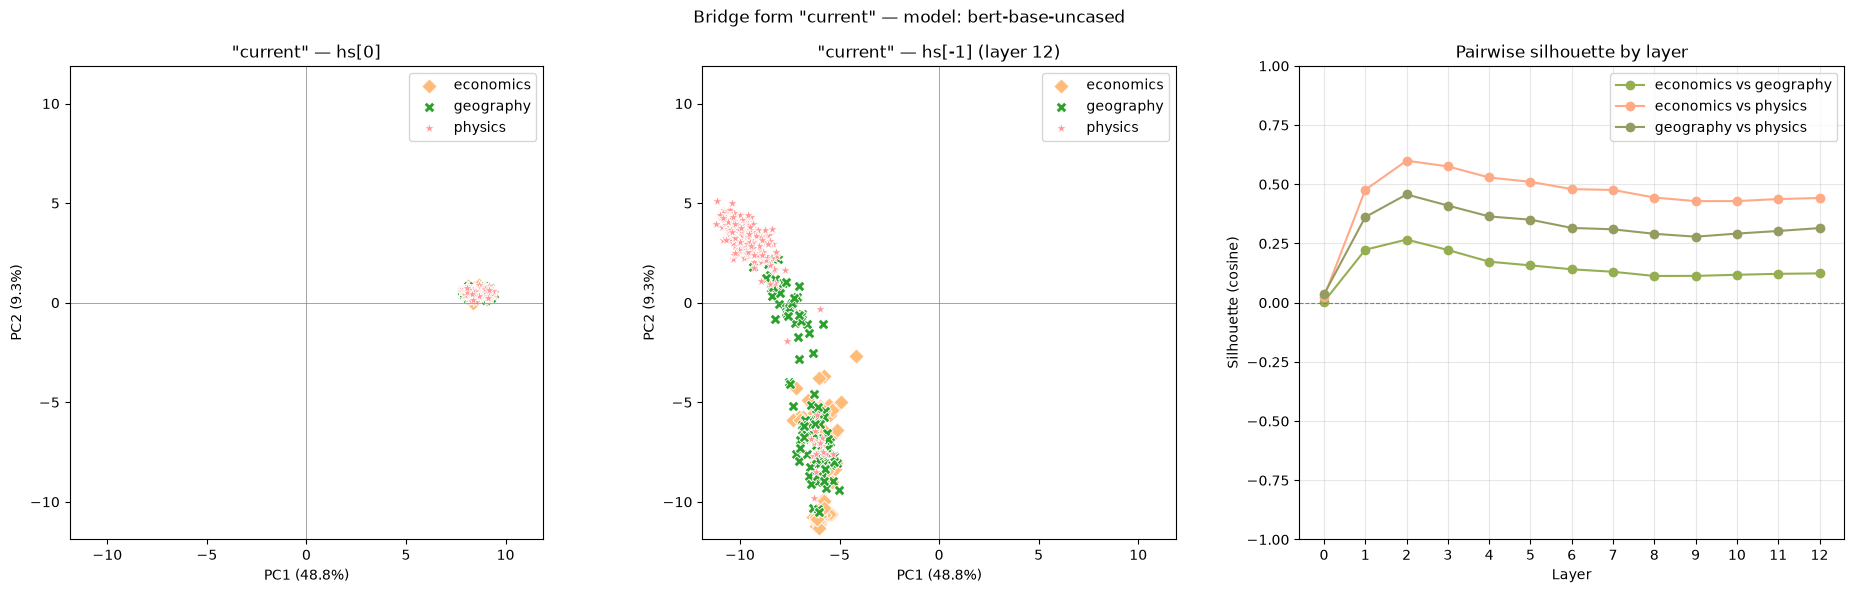

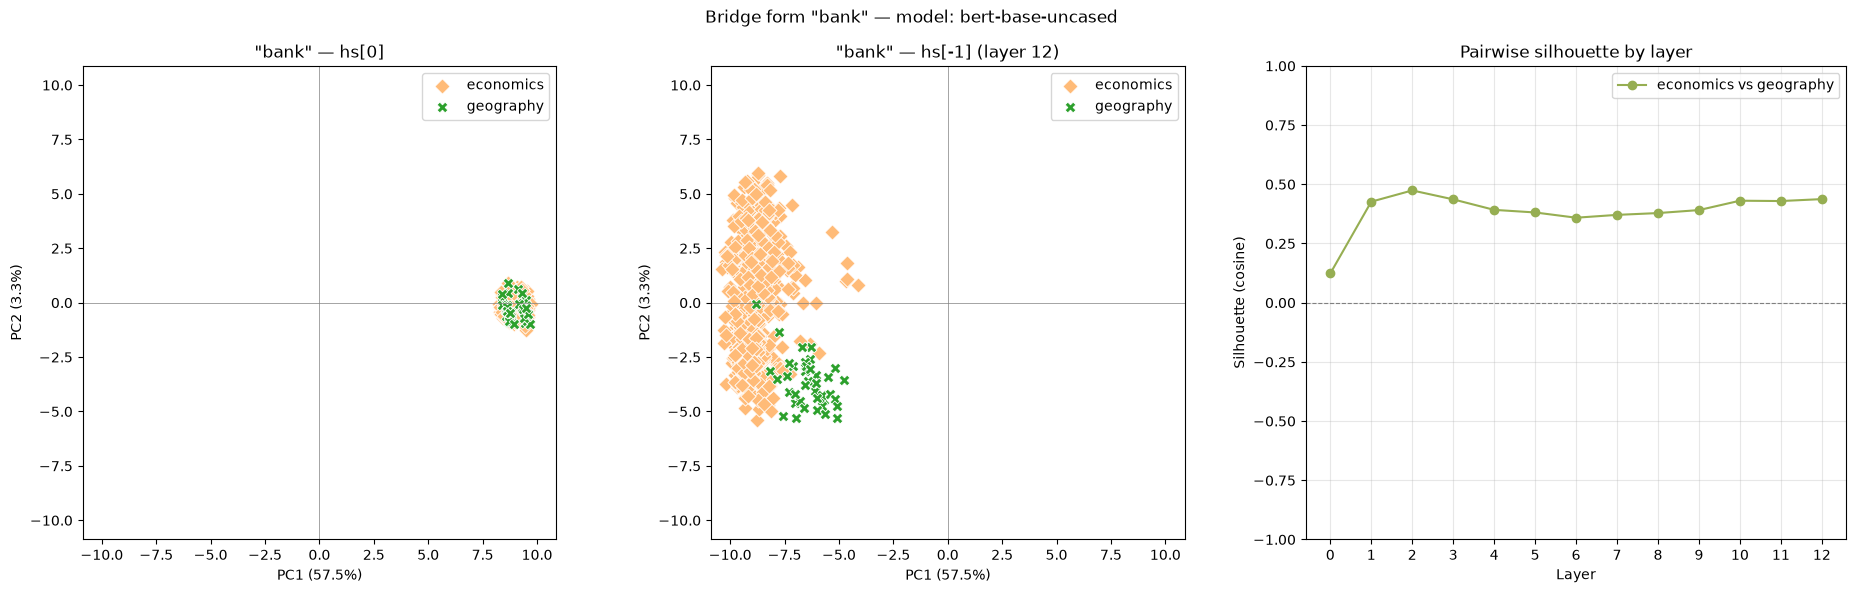

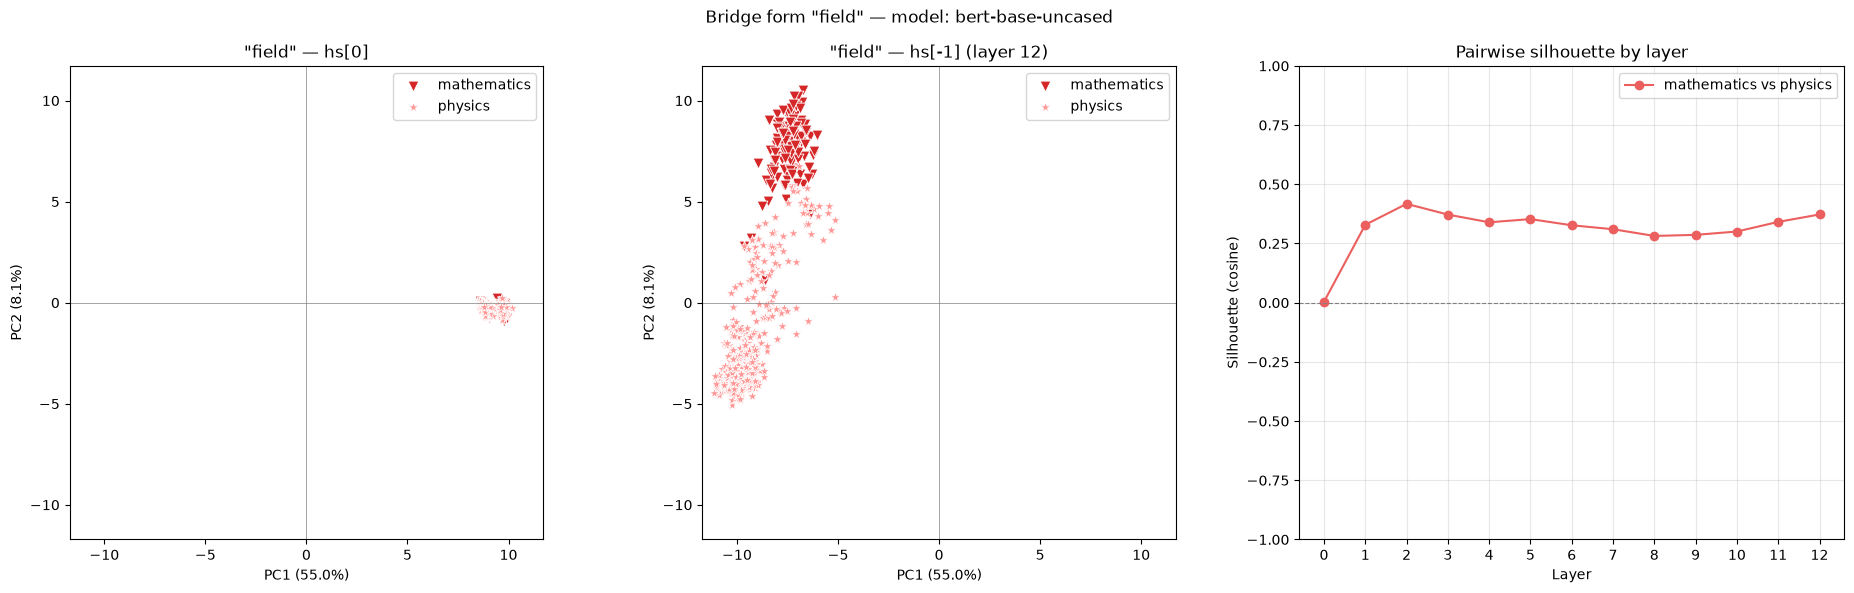

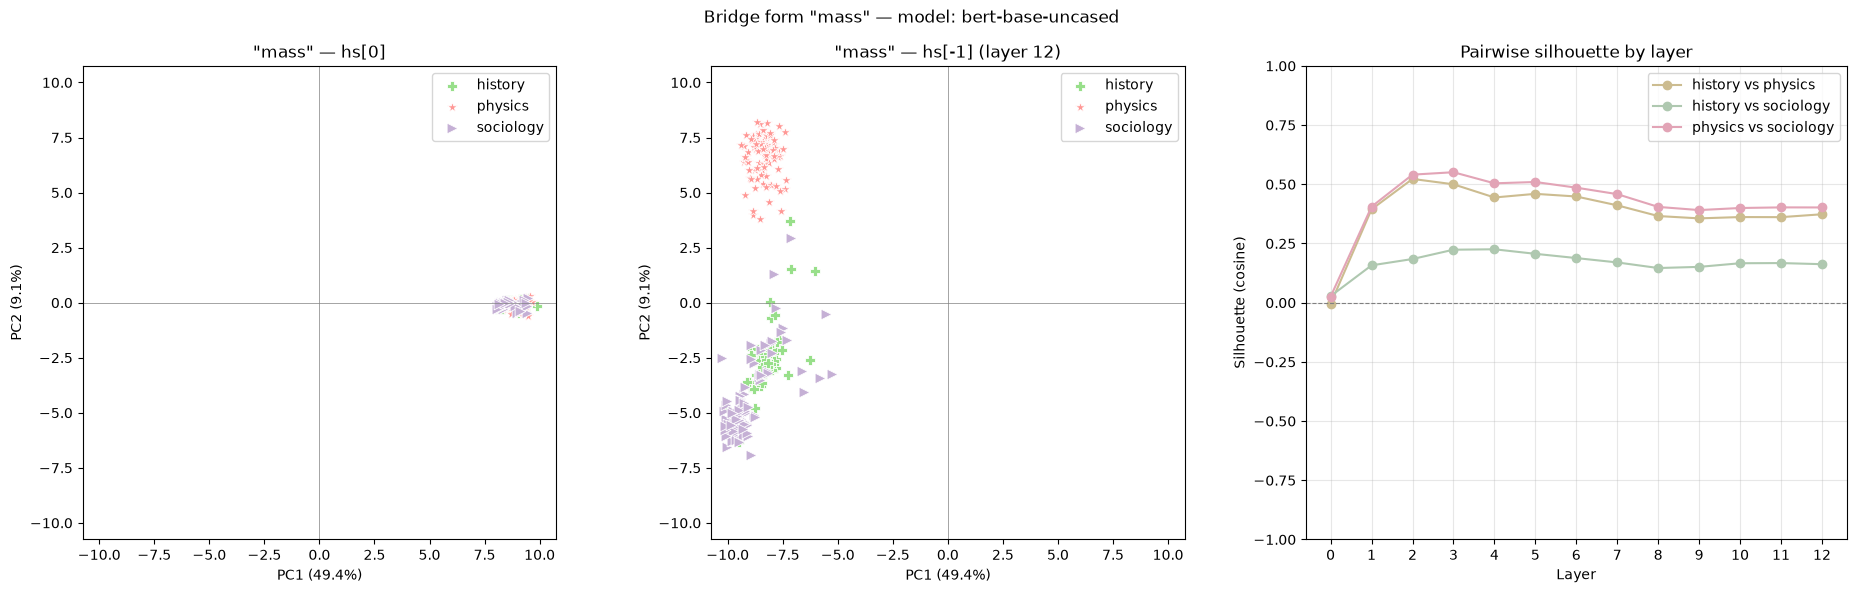

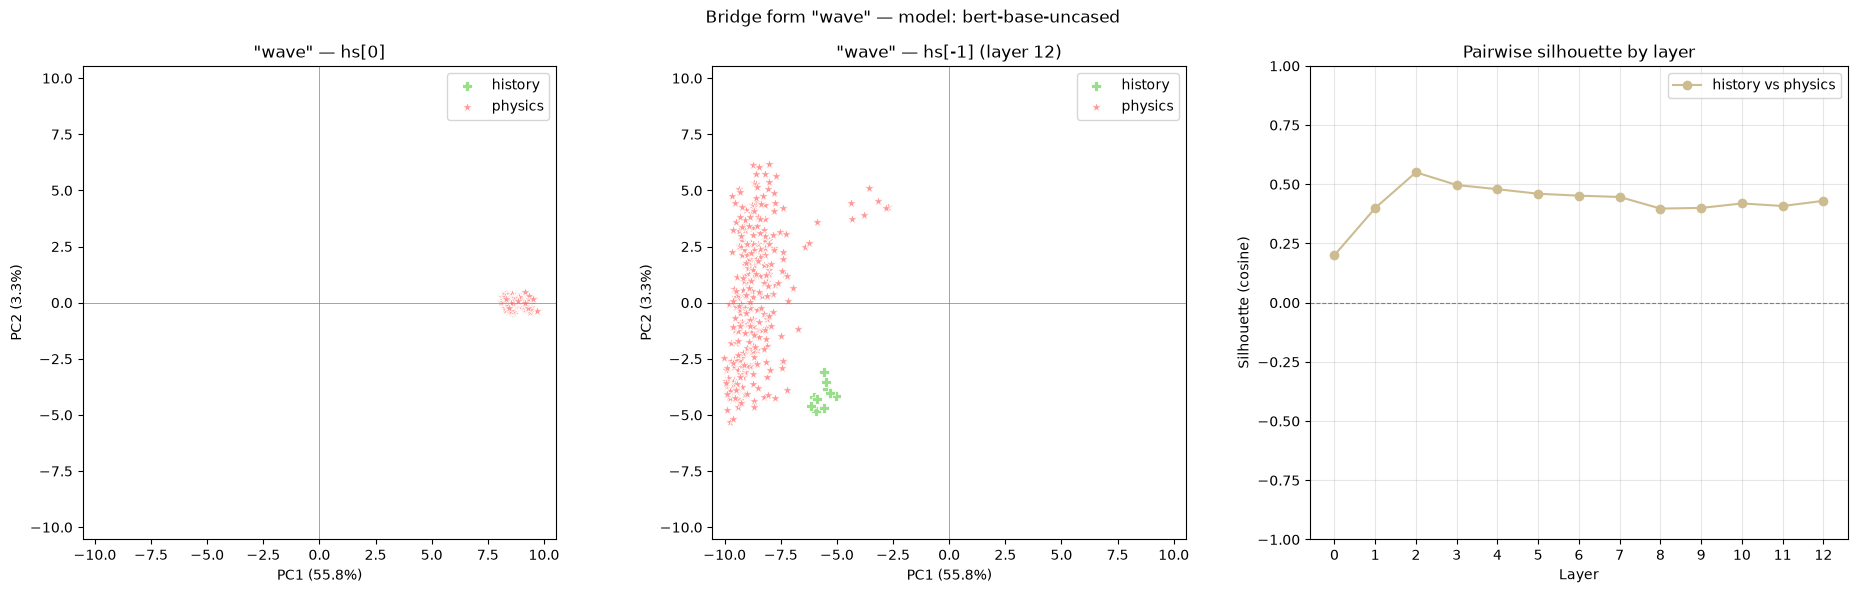

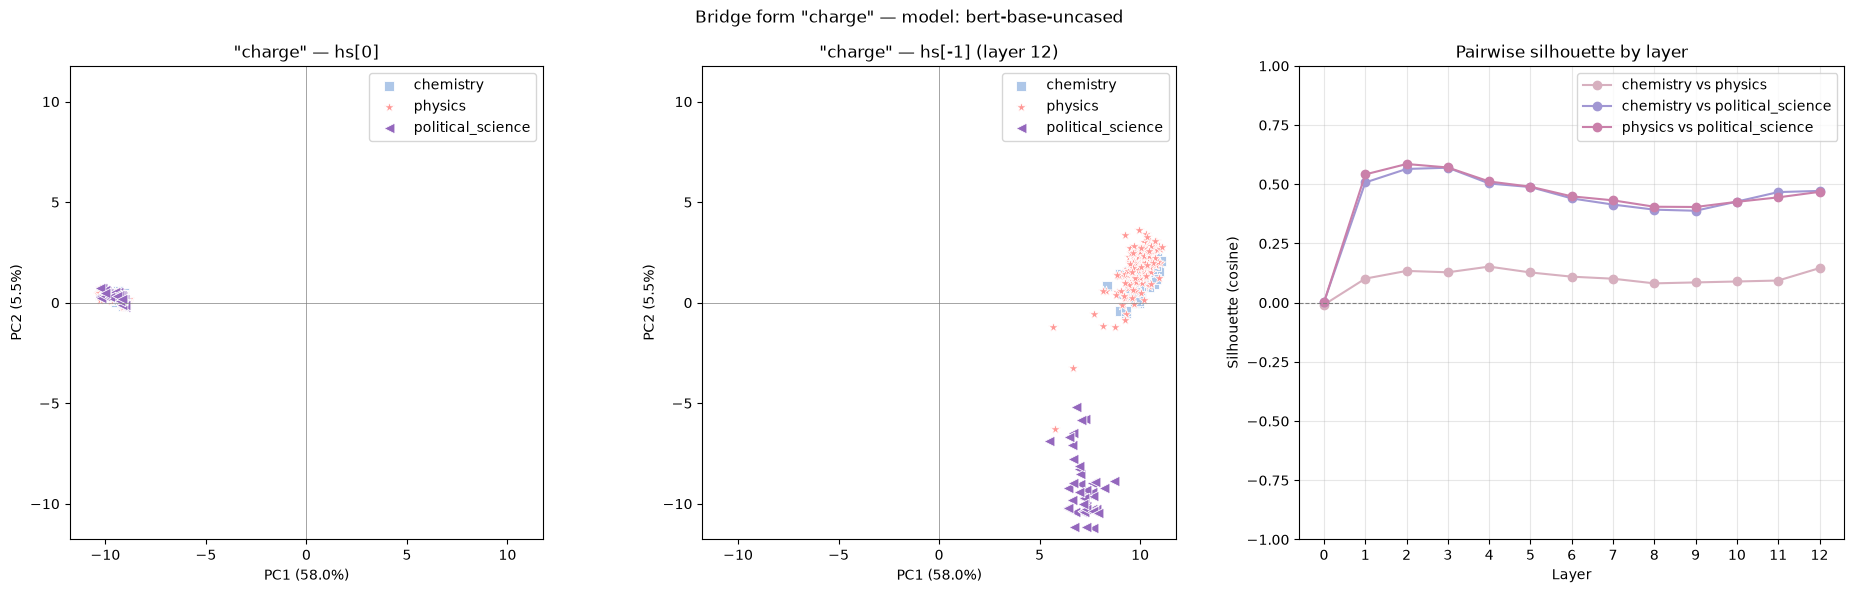

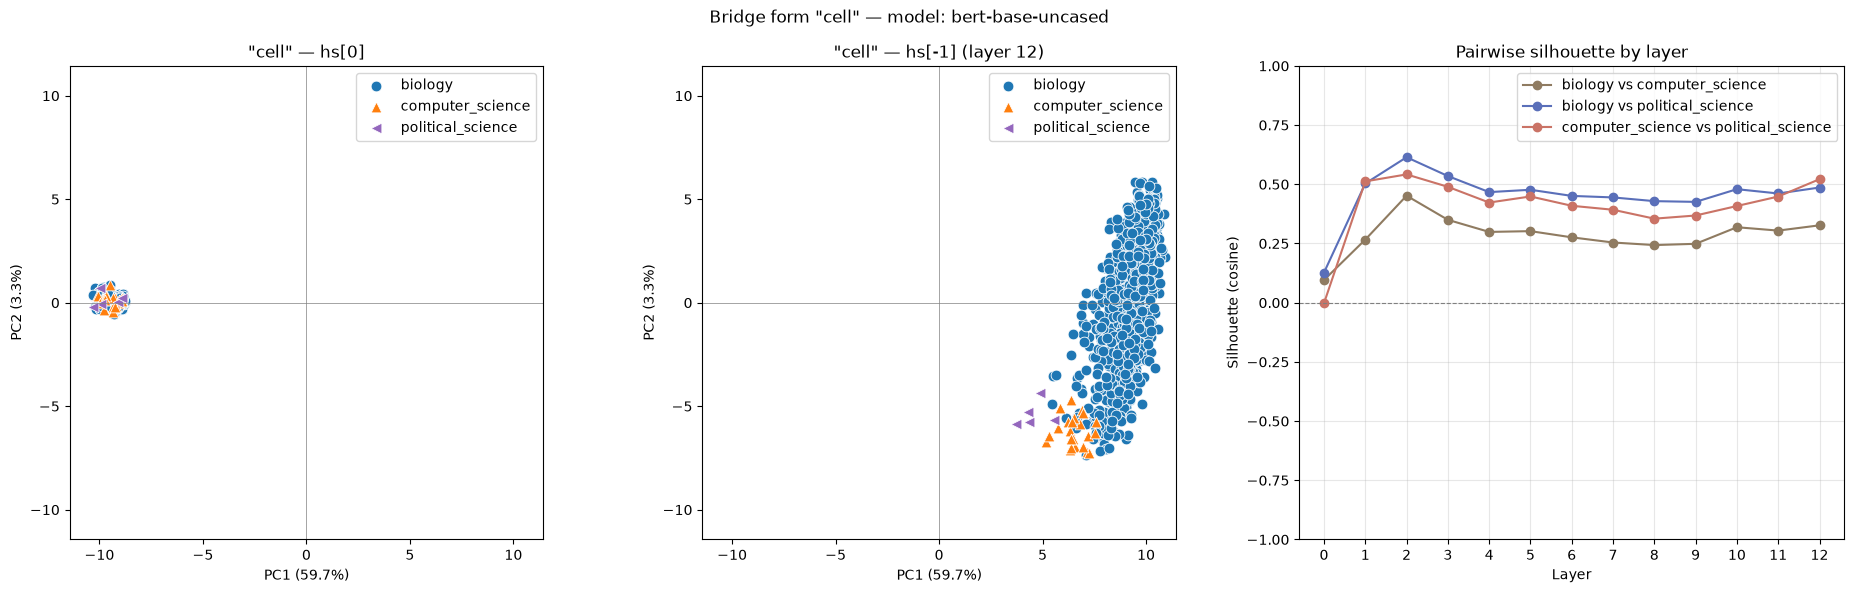

In [10]:
for form in BRIDGE_FORMS:
    plot_bridge_form_summary(bridge_vectors, form, MODEL_NAME)